# S05 : Reaction Rules as Graph Rewriting


## Aim of this talktorial

This talktorial (**S05**) introduces **Double Pushout (DPO) graph rewriting** as a formal way to turn reaction rules into exact, atom-mapped graph transformations.

The key idea is to represent a reaction rule as a span

$$
L \xleftarrow{\,l\,} K \xrightarrow{\,r\,} R,
$$

where $L$ is the pattern before the rewrite, $R$ is the pattern after the rewrite, and $K$ is the conserved interface that glues the transformation together.

Concretely, we focus on:

1. **Rules as spans**  
   Interpreting $L$, $K$, and $R$ chemically as deleted, preserved, and added structure.

2. **Injective matching and symmetry**  
   Finding all valid matches $m: L \hookrightarrow G$ in a host molecule and understanding duplicate matches caused by automorphism.

3. **Pushout complement**  
   Deleting $L \setminus K$ from the host while checking the dangling condition.

4. **Pushout construction**  
   Gluing $R \setminus K$ onto the preserved context to obtain the rewritten product graph.

5. **Atom mapping from node identity**  
   Preserving node identities through the rewrite so atom maps arise naturally from the graph transformation.

6. **Inverse application and SynKit tooling**  
   Applying rules in reverse and comparing the hand-built DPO workflow with `SynReactor`.

---

## Learning outcomes

After completing this talktorial, you will be able to:

- write a reaction rule as `L`, `K`, and `R`, and state what is deleted, preserved, and added,
- find injective rule matches in a host molecule,
- identify symmetry-related matches and choose canonical representatives,
- build the **pushout complement** and check the dangling condition,
- construct the **pushout** product graph, and
- chain the steps into a single pipeline that produces exact atom maps.

---

## Outline

<ul class="synedu-outline">
  <li><a href="#0-setup--data">0. Setup &amp; Data</a></li>
  <li><a href="#1-reaction-rules">1. Reaction rules</a></li>
  <li><a href="#2-double-pushout-graph-rewriting">2. Double Pushout Graph Rewriting</a></li>
  <li><a href="#3-synkit">3. SynKit</a></li>
  <li><a href="#4-quiz">4. Quiz</a></li>
  <li><a href="#5-discussion">5. Discussion</a></li>
</ul>

## 0. Setup & Data

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Hashable, Iterable, List, Tuple, Optional

import networkx as nx
from networkx.algorithms import isomorphism as iso

from rdkit import Chem
from rdkit.Chem import Draw

import rdkit
from synedu.Utils.graph import print_graph_attributes

print("RDKit:", rdkit.__version__)
print("NetworkX:", nx.__version__)

RDKit: 2025.09.3
NetworkX: 3.6.1


**Example molecules used in this notebook**

We will use a classic *pericyclic* transformation:

- **Diene**: butadiene (SMILES: `C=CC=C`)
- **Dienophile**: ethene (SMILES: `C=C`)
- Combined as a disconnected reactant mixture: `C=CC=C.C=C`

> Chemistry caveat: this is a toy model (no stereochemistry, no substituents, no endo/exo control).
The point is to demonstrate **bond reorganisation** under a rule-based graph rewriting view.


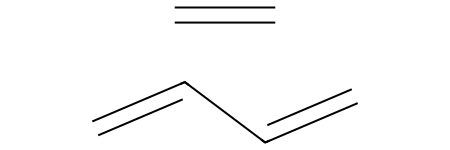

Reactant SMILES (canonical-ish): C=C.C=CC=C


In [2]:
reactant_smiles = "C=CC=C.C=C"
react = Chem.MolFromSmiles(reactant_smiles)
Chem.SanitizeMol(react)

display(react)
print("Reactant SMILES (canonical-ish):", Chem.MolToSmiles(react))

## 1. Reaction rules

A reaction rule is a **DPO span**
$$
L \xleftarrow{\;\ell\;} K \xrightarrow{\;r\;} R,
$$
where $L$ is the reacting pattern, $R$ the replacement, and $K$ the preserved
**context**.

Chemically:
$$
V_K = \text{atoms with conserved identity},
$$
$$
E_L\setminus E_K = \text{bonds broken},\qquad
E_R\setminus E_K = \text{bonds formed}.
$$
Bond-order changes appear as deletion in $L$ and creation in $R$ with endpoints fixed in $K$.

Now we will use a classic *pericyclic* transformation:

- **Diene**: butadiene (SMILES: `C=CC=C`)
- **Dienophile**: ethene (SMILES: `C=C`)
- **Product**: cyclohexen(SMILES: `C1C=CCCC1`)

**Definition (DPO Reaction Rule / Span).**  
A *DPO reaction rule* is a pair of injective graph morphisms

$$
p:\quad L \xleftarrow{\;l\;} K \xrightarrow{\;r\;} R
$$

where $L$, $K$, $R$ are labeled graphs (with node attributes $\mathbf{a}$ and edge attributes $\mathbf{b}$), $l: K \hookrightarrow L$ and $r: K \hookrightarrow R$ are inclusions.

- $K$ — the *gluing graph* or *interface*: atoms and bonds **preserved** by the reaction  
- $L \setminus l(K)$ — atoms and bonds **consumed** (deleted) in the left-hand side  
- $R \setminus r(K)$ — atoms and bonds **produced** (created) in the right-hand side  

**Definition (Pattern Match).**  
A *match* of rule $p$ in a host graph $G$ is an injective graph morphism $m: L \hookrightarrow G$ that is *label-preserving*. A match is *valid* if it satisfies the **dangling condition**: no edge $e \in E(G)$ is incident to a deleted node $m(v)$, $v \in V(L) \setminus V(K)$, without also being in $m(E(L))$.

**Definition (DPO Rewriting Step).**  
Given a valid match $m: L \hookrightarrow G$, the *DPO rewriting step* $G \Rightarrow_p H$ produces the result graph $H$ by the double pushout construction:

$$
L \xleftarrow{l} K \xrightarrow{r} R
\quad\Big\Updownarrow\quad
G \xleftarrow{m} D \xrightarrow{} H
$$

where $D = G \setminus m(L \setminus K)$ is the *pushout complement* (host minus deleted items) and $H$ is obtained by gluing $R$ to $D$ along $K$.


<figure style="text-align: center;">
  <img src="../../docs/_static/S05/diels_alder_dpo.svg"
       alt="DPO span anatomy — Diels–Alder"
       style="width: 100%; max-width: 900px;">
  <figcaption>
    <b>Figure 1.</b> DPO span for the Diels&#x2013;Alder reaction: rule span
    <i>L</i> &larr;<sup><i>l</i></sup> <i>K</i> &rarr;<sup><i>r</i></sup> <i>R</i> (top)
    and its application
    <i>G</i> &larr;<sup><i>g</i></sup> <i>D</i> &rarr;<sup><i>h</i></sup> <i>H</i> (bottom).
    Red bonds are broken; green bonds are formed; grey nodes/bonds are preserved context.
  </figcaption>
</figure>

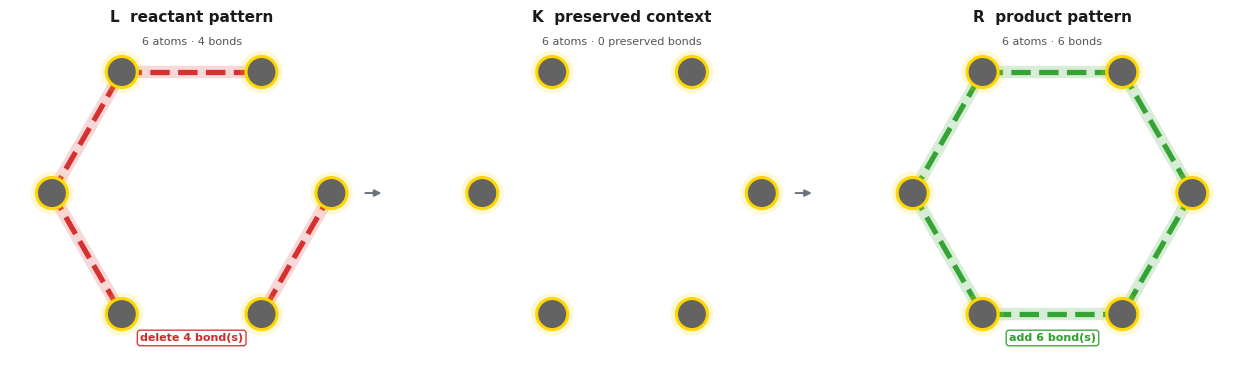

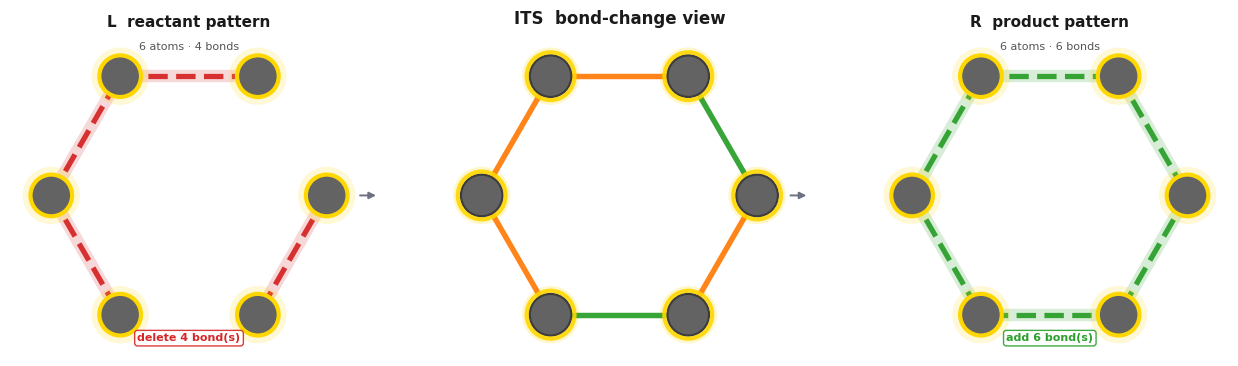

In [3]:
from synedu.Utils.reaction import rsmi_to_graph
from synedu.Utils.Vis.dpo import visualize_dpo_rule

# Now we define left and right patterns with atom map
aam = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
L, R = rsmi_to_graph(aam)

axes, dec, pos, its = visualize_dpo_rule(
    L,
    R,
    use_its=False,
    title=None,
    show_legends=False,
    show_edge_labels=False,
    show_node_labels=False,
    node_size=500,
)
axes, dec, pos, its = visualize_dpo_rule(
    L,
    R,
    use_its=True,
    title=None,
    show_legends=False,
    show_edge_labels=False,
    show_node_labels=False,
)

In [4]:
from __future__ import annotations

from typing import Tuple
import networkx as nx


def _get_k(
    L: nx.Graph,
    R: nx.Graph,
    *,
    order_key: str = "order",
    keep_k_node_attrs: Tuple[str, ...] = ("element", "aromatic", "atom_map"),
) -> nx.Graph:
    """
    Build interface graph K from L and R as:
      - nodes: intersection of node IDs
      - edges: intersection of edge endpoint pairs
      - edge order in K: min(order_L, order_R)

    This matches your desired behavior (e.g. 2.0 in L and 1.0 in R -> 1.0 in K).
    """
    K = nx.Graph()

    # nodes in both
    common_nodes = set(L.nodes()) & set(R.nodes())
    for n in common_nodes:
        # Prefer L's attrs, fallback to R; keep only stable attrs
        d = dict(L.nodes[n]) if n in L.nodes else {}
        if not d and n in R.nodes:
            d = dict(R.nodes[n])
        K.add_node(n, **{k: d[k] for k in keep_k_node_attrs if k in d})

    # edges in both (by unordered endpoints)
    common_edges = set(L.edges()) & set(R.edges())
    for u, v in common_edges:
        ol = L.edges[u, v].get(order_key, 0.0)
        orr = R.edges[u, v].get(order_key, 0.0)
        K.add_edge(u, v, **{order_key: float(min(ol, orr))})

    return K


# usage:
K = _get_k(L, R)
print_graph_attributes(K)

Graph: 6 nodes, 4 edges
Nodes:
  1: element='C', aromatic=False, atom_map=1
  2: element='C', aromatic=False, atom_map=2
  3: element='C', aromatic=False, atom_map=3
  4: element='C', aromatic=False, atom_map=4
  5: element='C', aromatic=False, atom_map=5
  6: element='C', aromatic=False, atom_map=6
Edges:
  (1, 2): order=1.0
  (2, 3): order=1.0
  (3, 4): order=1.0
  (5, 6): order=1.0


## 2. Double Pushout Graph Rewriting

Two categorical pushouts compactly encode the familiar chemical workflow **delete → add** (remove broken bonds / atoms, then glue in the new fragment). The usual DPO diagram is:

$$
\begin{array}{ccccc}
\displaystyle L & \xleftarrow{\;\ell\;} & \displaystyle K & \xrightarrow{\;r\;} & \displaystyle R \\[10pt]
\displaystyle \downarrow^{m} & & \displaystyle \downarrow^{m'} & & \displaystyle \downarrow^{m''} \\[10pt]
\displaystyle G & \xleftarrow{\;g\;} & \displaystyle D & \xrightarrow{\;h\;} & \displaystyle H
\end{array}
$$

- $L$ — **left-hand side** (pattern to match: atoms/bonds that may be deleted or preserved).  
- $R$ — **right-hand side** (pattern to be inserted).  
- $K$ — **interface / context** (the part preserved during the rewrite: $K\subseteq L,R$).  
- $m$ — the **match** $L\hookrightarrow G$ (where the rule is found inside the host graph $G$).  
- $D$ — the **pushout complement** (result of deleting $L\setminus K$ from $G$).  
- $H$ — the **product graph** after the rewrite.


**Chemical intuition**

1. find the pattern $L$ in molecule $G$ (this chooses *where* the chemistry happens);  
2. remove the atoms/bonds that should disappear (everything in $L\setminus K$) — this is the **deletion** step;  
3. attach the new fragment $R\setminus K$ to the remaining context $K$ — this is the **addition** step;  
4. the result $H$ is the new molecule after the transformation.


**Formal constraints**

1. *Injective match*
The mapping $m:L\hookrightarrow G$ must be **injective** (no two distinct nodes in $L$ map to the same node of $G$). This prevents unwanted atom merging.

2. *Dangling condition (no half-bonds)*
If a node of $G$ is removed, we must not leave an edge with only one endpoint. Formally:

$$ 
   \forall\ \{x,y\}\in E(G):\qquad \big(x\in S\big)\Longrightarrow\big(y\in S\big).
   $$

   or, symmetrically,
   $$
   E(G)\cap\bigl(S\times (V(G)\setminus S)\bigr)=\varnothing.
   $$

Equivalently: every edge adjacent to a deleted node must also be deleted (i.e., both endpoints are deleted), otherwise you would create a dangling (half) bond.

3. *Chemical sanity after rewrite*
After forming $H$ check chemical invariants you care about (valence bounds, formal charge consistency, stereochemistry handling, etc.). These are *domain-specific* checks not enforced by the abstract DPO construction.



Now we try with Diels Alder reaction as an example

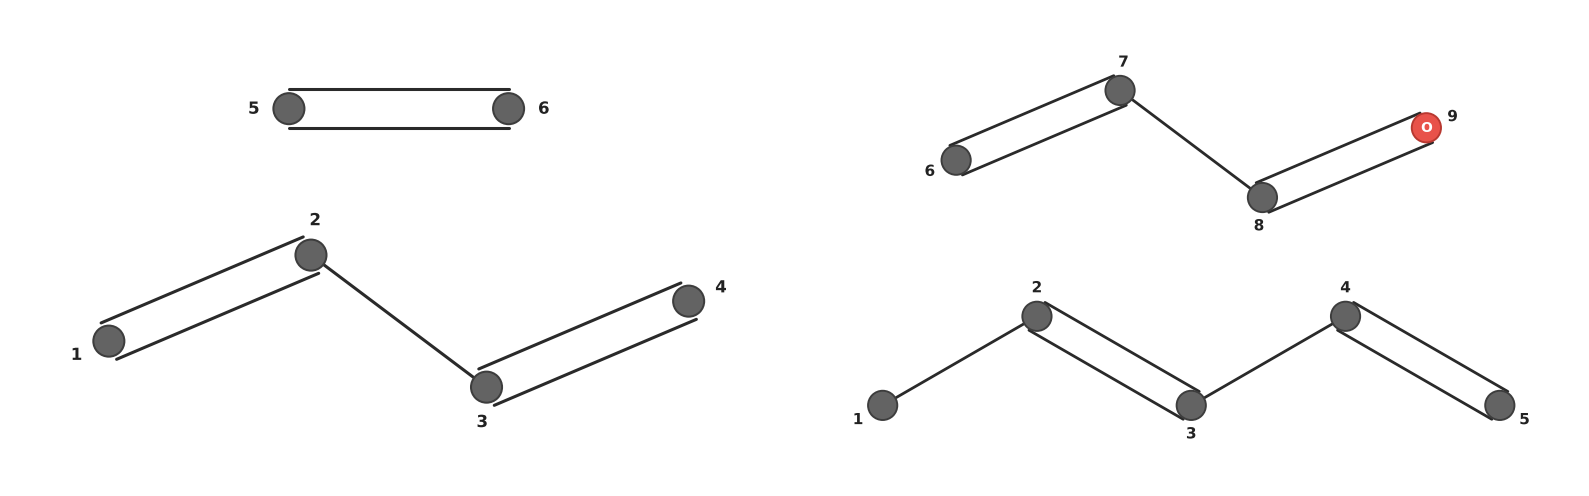

In [5]:
from synedu.Utils.conversion import smiles_to_graph
from synedu.Utils.vis import draw_molecular_graph

# for simple modeling, we use reaction that does not require hydrogen
input = 'CC=CC=C.C=CC=O'

G = smiles_to_graph(input)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

draw_molecular_graph(
    L,
    show_indices=True,
    ax=ax[0],
)

draw_molecular_graph(
    G,
    show_indices=True,
    ax=ax[1],
)

plt.tight_layout()

### 2.1. Pattern matching (where a rule applies)

A reaction rule is given as a span
$$
p := \bigl( L \xleftarrow{\;\ell\;} K \xrightarrow{\;r\;} R \bigr),
$$
where $L$ is the reactant pattern, $R$ the product pattern, and $K$ the
interface of conserved atoms.

Given a host (reactant) molecular graph $G$, the rule applies at any
**injective match**
$$
m : L \hookrightarrow G,
$$
that is, a labeled subgraph monomorphism embedding the reaction pattern $L$
into the host graph $G$ and thereby identifying the reaction center.


In [6]:
from typing import Any, Callable, Dict, List

import networkx as nx
from networkx.algorithms import isomorphism as iso


def node_match(L_node: dict, G_node: dict) -> bool:
    eL = L_node.get("element")
    eG = G_node.get("element")
    return (eL is None) or (eG is None) or (eL == eG)


def edge_match(L_edge: dict, G_edge: dict) -> bool:
    oL = L_edge.get("order")
    oG = G_edge.get("order")
    return (oL is None) or (oG is None) or (float(oL) == float(oG))


def _automorphisms(
    H: nx.Graph,
    *,
    node_match: Callable[[dict, dict], bool],
    edge_match: Callable[[dict, dict], bool],
) -> List[Dict[Any, Any]]:
    GM = iso.GraphMatcher(H, H, node_match=node_match, edge_match=edge_match)
    return list(GM.isomorphisms_iter())  # H -> H

In [7]:
from synedu.Utils.graph import enumerate_automorphisms

**Q1 — Pattern match**

Implement `find_pattern_match(G, L)` using `node_match`, `edge_match`, `_automorphisms`; enumerate all injective embeddings $m: L \hookrightarrow G$ and yield one canonical representative per `Aut(L)` orbit, then run on the given `L`/`G`.

---

<details> <summary><b>Solution:</b></summary>

```python
def find_pattern_match(G: nx.Graph, L: nx.Graph) -> Iterable[Dict[Any, Any]]:
    """Yield one representative per Aut(L)-orbit of subgraph monomorphisms L -> G."""
    # automorphisms of L (L -> L)
    auts = list(iso.GraphMatcher(L, L, node_match=node_match, edge_match=edge_match).isomorphisms_iter())
    L_nodes = tuple(sorted(L.nodes()))
    seen: Set[Tuple[Any, ...]] = set()

    # find embeddings (G -> L -> invert to L -> G)
    GM = iso.GraphMatcher(G, L, node_match=lambda Gd, Ld: node_match(Ld, Gd),
                                  edge_match=lambda Gd, Ld: edge_match(Ld, Gd))
    for m_G_to_L in GM.subgraph_isomorphisms_iter():
        m = {l: g for g, l in m_G_to_L.items()}  # L -> G
        key = min((tuple(m[a[n]] for n in L_nodes) for a in auts), default=tuple(m[n] for n in L_nodes))
        if key in seen:
            continue
        seen.add(key)
        yield m

maps  = find_pattern_match(G, L)
for i in maps:
    print(i)
```
Output
```text
{5: 6, 6: 7, 2: 3, 3: 4, 4: 5, 1: 2}
```

- `raw` lists all injective embeddings (here: **4** raw maps).  
- **Do not** quotient by the full `Aut(L)` when `L` is disconnected — that mixes symmetries across fragments and over-collapses distinct placements.  
- **Fix (generic):** choose **one anchor component** (e.g. largest or explicit `anchor_nodes`) and **do not** quotient that component; quotient only the other components by their own `Aut`.  
- Use a component-aware matcher (e.g. `find_pattern_match_components(anchor="largest")`).  
- With this policy your example yields **2** canonical maps (diene orientations kept distinct, ethene deduped) instead of 1.

</details>

In [8]:
import itertools
import networkx as nx
from networkx.algorithms import isomorphism as iso


def find_pattern_match_components(
    host: nx.Graph,
    pattern: nx.Graph,
    *,
    anchor: str = "largest",
):
    """
    Split the pattern into connected components; keep raw matches for the
    anchor component (so its placements stay distinct), but quotient other
    components by Aut(component).

    Returns
    -------
    list[dict]
        Each dict is a node mapping {pattern_node -> host_node}.
    """
    # --- split pattern into connected components ---
    comps = [pattern.subgraph(ns).copy() for ns in nx.connected_components(pattern)]

    if anchor == "largest":
        anchor_idx = max(
            range(len(comps)),
            key=lambda i: (comps[i].number_of_nodes(), comps[i].number_of_edges()),
        )
    else:
        anchor_idx = 0

    comp_reps = []

    # --- compute representatives per component ---
    for i, C in enumerate(comps):
        matcher = iso.GraphMatcher(
            host,
            C,
            node_match=lambda Hd, Cd: node_match(Cd, Hd),
            edge_match=lambda Hd, Cd: edge_match(Cd, Hd),
        )

        # raw matches: pattern_node -> host_node
        raw = [
            {c: h for h, c in m.items()} for m in matcher.subgraph_isomorphisms_iter()
        ]

        if i == anchor_idx:
            reps = raw
        else:
            auts = _automorphisms(C, node_match=node_match, edge_match=edge_match)
            C_nodes = tuple(sorted(C.nodes()))

            seen_keys = set()
            reps = []

            for m in raw:
                # canonical key under automorphism action
                key = min(
                    (tuple(m[a[v]] for v in C_nodes) for a in auts),
                    default=tuple(m[v] for v in C_nodes),
                )

                if key in seen_keys:
                    continue

                seen_keys.add(key)
                reps.append(m)

        comp_reps.append(reps)

    # --- combine component matches ---
    results = []

    for choice in itertools.product(*comp_reps):
        used = set()
        out = {}
        ok = True

        for m in choice:
            vals = set(m.values())
            if used & vals:
                ok = False
                break
            used |= vals
            out.update(m)

        if ok:
            results.append(out)

    return results

In [9]:
matches = find_pattern_match_components(G, L)
matches

[{5: 6, 6: 7, 2: 3, 3: 4, 4: 5, 1: 2}, {5: 6, 6: 7, 2: 4, 3: 3, 4: 2, 1: 5}]

#### Pattern match gallery — all valid matches of $L$ in $G$

We enumerate all injective matches $m: L \hookrightarrow G$ and display each one,
highlighting the matched subgraph in $G$. Orbit-deduplication then collapses
symmetry-equivalent matches.

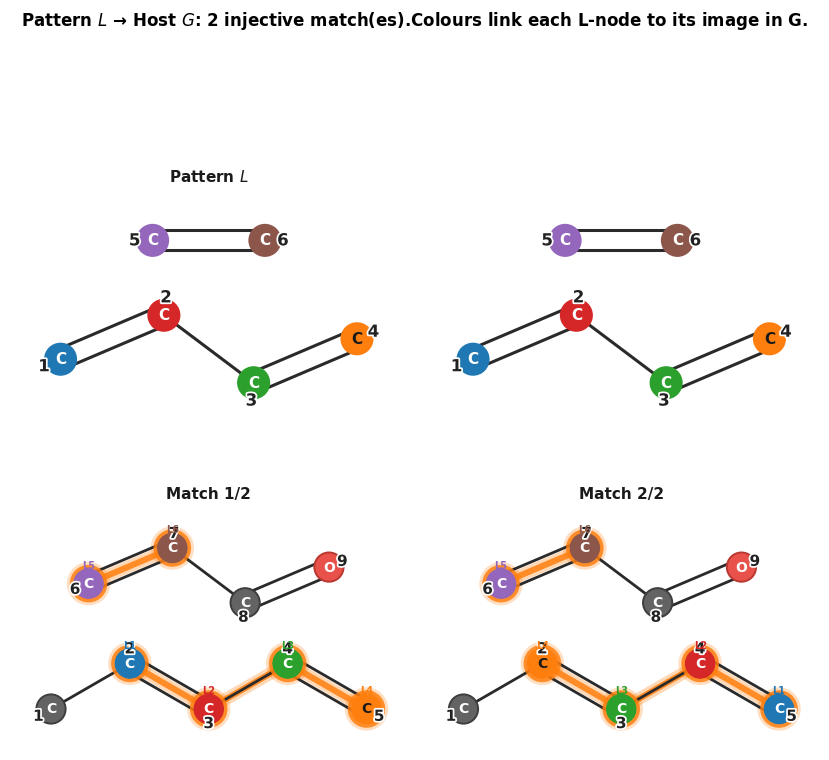

Total injective matches: 2


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from synedu.Utils.vis import draw_molecular_graph, _layout_from_graph_mol

# ── colour palette: one colour per L-node ────────────────────────────────────
_PAL = [
    "#1F77B4",
    "#D62728",
    "#2CA02C",
    "#FF7F0E",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#17BECF",
]

_all_matches = find_pattern_match_components(G, L)
_n_raw = len(_all_matches)
_show = _all_matches[: min(4, _n_raw)]

_L_nodes = sorted(L.nodes())
_l_color = {n: _PAL[i % len(_PAL)] for i, n in enumerate(_L_nodes)}

# ── layout: row 0 = L replicated, row 1 = G with coloured match ──────────────
_ncols = len(_show)
fig = plt.figure(figsize=(_ncols * 4.2, 8.5), facecolor="white")
fig.suptitle(
    f"Pattern $L$ → Host $G$: {_n_raw} injective match(es)."
    "Colours link each L-node to its image in G.",
    fontsize=12,
    fontweight="bold",
)

# pre-compute G layout once (same as draw_molecular_graph uses internally)
_G_pos = _layout_from_graph_mol(G, sorted(G.nodes()))

for k, match in enumerate(_show):
    # ── left: pattern L ──────────────────────────────────────────────────────
    ax_L = fig.add_subplot(2, _ncols, k + 1)
    draw_molecular_graph(
        L,
        ax=ax_L,
        custom_node_colors=_l_color,
        label_mode="all",
        show_indices=True,
        title="Pattern $L$" if k == 0 else "",
    )
    if k == 0:
        ax_L.set_ylabel("Pattern", fontsize=10, labelpad=4)

    # ── right: host G, matched nodes painted in their L-node colour ──────────
    ax_G = fig.add_subplot(2, _ncols, _ncols + k + 1)

    _inv = {g_node: _l_color[l_node] for l_node, g_node in match.items()}
    _hl_nodes = set(match.values())
    _hl_edges = {(u, v) for u, v in G.edges() if u in _hl_nodes and v in _hl_nodes}

    draw_molecular_graph(
        G,
        ax=ax_G,
        custom_node_colors=_inv,
        highlight_nodes=_hl_nodes,
        highlight_edges=_hl_edges,
        label_mode="all",
        show_indices=True,
        title=f"Match {k + 1}/{_n_raw}",
    )
    if k == 0:
        ax_G.set_ylabel("Host $G$", fontsize=10, labelpad=4)

    # annotate each matched G-node with its L counterpart using the real layout
    for l_node, g_node in sorted(match.items()):
        x, y = _G_pos[g_node]
        ax_G.annotate(
            f"L{l_node}",
            xy=(x, y),
            xytext=(x, y + 0.22),
            fontsize=7,
            ha="center",
            va="bottom",
            color=_l_color[l_node],
            fontweight="bold",
            zorder=15,
            annotation_clip=False,
        )

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
print(f"Total injective matches: {_n_raw}")

### 2.2. Pushout Complement

Given graphs $L$, $K \subseteq L$, a host graph $G$, and an injective match
$$
m : L \hookrightarrow G,
$$
the **pushout complement** is
$$
D = G \setminus m(L \setminus K),
$$
if it exists.

**Deletion**
$$
V_{\text{del}} = m\!\left(V(L)\setminus V(K)\right), \qquad
E_{\text{del}} = \{\, e=\{u,v\}\in E(G)\mid u\in V_{\text{del}} \ \text{or}\ v\in V_{\text{del}} \,\}.
$$
$$
D = \bigl(V(G)\setminus V_{\text{del}},\; E(G)\setminus E_{\text{del}}\bigr),
$$
with all attributes and node IDs inherited from \(G\).

**Dangling condition**
$$
\forall\, \{u,v\}\in E(G):\quad
u\in V_{\text{del}} \Rightarrow v\in V_{\text{del}}.
$$

**Interface map**
$$
m' : K \hookrightarrow D, \qquad m'(v)=m(v)\ \ \forall v\in V(K).
$$



#### Example — Dangling condition

Consider a **molecular graph** (ethanol):

$$
G:\quad \mathrm{C_1{-}C_2{-}O_3}
$$

Edges:
$$
E(G)=\{\{C_1,C_2\},\{C_2,O_3\}\}
$$

---

#### Invalid pushout complement (dangling)

Let
$$
L = \{C_2\}, \qquad K=\varnothing,
$$
with injective match
$$
m(C_2)=C_2.
$$

Then
$$
V_{\text{del}}=\{C_2\}.
$$

But in $G$:
$$
\{C_2,O_3\}\in E(G),\quad
C_2\in V_{\text{del}},\; O_3\notin V_{\text{del}}.
$$

This would leave a **dangling bond** at $O_3$.

❌ **Dangling condition violated → no pushout complement.**

---

#### Valid pushout complement (corrected)

Consider the ethanol host graph
$$
G:\quad \mathrm{C_1{-}C_2{-}O_3}.
$$

Let the rule delete the **entire molecule**:
$$
L=\{C_1,C_2,O_3\}, \qquad K=\varnothing,
$$
with injective match
$$
m(C_1)=C_1,\; m(C_2)=C_2,\; m(O_3)=O_3.
$$

Then
$$
V_{\text{del}}=\{C_1,C_2,O_3\}.
$$

Every edge of \(G\) is incident to deleted nodes and is contained in \(m(E(L))\),
so no half-edges are created.

Remaining graph:
$$
D=\varnothing.
$$

✅ **Dangling condition satisfied.**



**Q2 — Dangling condition**

Implement `violates_dangling(G, L, K, m)` to verify whether a given match `m : L -> G`
violates the DPO dangling condition (i.e. some edge in `G` is incident to a deleted node
but is not deleted as part of `L \ K`).

---

<details> <summary><b>Solution</b></summary>

```python
import networkx as nx
from typing import Dict, Hashable, Set, FrozenSet

def violates_dangling(
    G: nx.Graph,
    L: nx.Graph,
    K: nx.Graph,
    m: Dict[Hashable, Hashable],  # L.node -> G.node
) -> bool:
    
    # basic sanity checks
    if not set(K.nodes).issubset(set(L.nodes)):
        raise ValueError("K must be a subgraph of L (K.nodes ⊆ L.nodes).")
    if set(m.keys()) != set(L.nodes) and not set(L.nodes).issubset(set(m.keys())):
        # allow m to be defined on a superset but require mapping for all L.nodes
        raise ValueError("Mapping m must provide an image for every node in L.")
    if len(set(m[v] for v in L.nodes)) != len(list(L.nodes)):
        raise ValueError("Mapping m must be injective on L.nodes.")

    # nodes to be deleted: image of L \ K
    V_del: Set[Hashable] = {m[v] for v in L.nodes if v not in K.nodes}

    # edges to be deleted: image of edges in L that are not fully contained in K
    E_del: Set[FrozenSet[Hashable]] = set()
    for u, v in L.edges:
        # if at least one endpoint lies in L\K, that L-edge will be removed
        if (u not in K.nodes) or (v not in K.nodes):
            E_del.add(frozenset({m[u], m[v]}))

    # check every edge in G: if it touches a deleted node it must be in E_del
    for u, v in G.edges:
        e = frozenset({u, v})
        if (u in V_del) or (v in V_del):
            if e not in E_del:
                return True
    return False


# 1) Invalid: delete only middle carbon -> dangling at O3
L1 = nx.Graph()
L1.add_node("c2")
K1 = nx.Graph()  # empty
m1 = {"c2": 2}
print("case1 (delete c2 only) ->", violates_dangling(G, L1, K1, m1))  # True

# 2) Invalid: delete c2 + o3 but L does NOT include edge {c1,c2} -> dangling at C1
L2 = nx.Graph()
L2.add_nodes_from(["c2", "o3"])
L2.add_edge("c2", "o3")
K2 = nx.Graph()  # empty
m2 = {"c2": 2, "o3": 3}
print("case2 (delete c2+o3 but L misses c1-c2) ->", violates_dangling(G, L2, K2, m2))  # True

# 3) Valid substitution: delete O3 (leaving group), preserve C1-C2 backbone
L3 = nx.Graph()
L3.add_nodes_from(["c1", "c2", "o3"])
L3.add_edges_from([("c1", "c2"), ("c2", "o3")])
K3 = nx.Graph()
K3.add_nodes_from(["c1", "c2"])
K3.add_edge("c1", "c2")
m3 = {"c1": 1, "c2": 2, "o3": 3}
print("case3 (substitution C-C-O -> C-C-? ) ->", violates_dangling(G, L3, K3, m3))  # False
```

</details>

In [11]:
from __future__ import annotations

from typing import Any, Dict, Iterable, List, Tuple
import networkx as nx


def pushout_complement(
    L: nx.Graph,
    K: nx.Graph,
    G: nx.Graph,
    m: Dict[Any, Any],
    *,
    order_key: str = "order",
    check_injective: bool = True,
    check_structure: bool = True,
    check_dangling_nodes: bool = True,
) -> Tuple[nx.Graph, Dict[Any, Any]]:
    # --- sanity: match covers L nodes ---
    missing = [u for u in L.nodes() if u not in m]
    if missing:
        raise KeyError(f"Match m missing images for L nodes: {missing}")

    if check_injective:
        imgs = list(m.values())
        if len(set(imgs)) != len(imgs):
            raise ValueError("Match m must be injective.")

    # --- node deletions ---
    del_L_nodes = set(L.nodes()) - set(K.nodes())
    del_G_nodes = {m[u] for u in del_L_nodes}

    # dangling condition for NODE deletions (half-bonds)
    if check_dangling_nodes:
        for gx in del_G_nodes:
            for gy in G.neighbors(gx):
                if gy not in del_G_nodes:
                    raise ValueError(
                        f"Dangling condition violated: deleting node {gx} leaves edge to preserved node {gy}."
                    )

    # --- edge sets (by unordered endpoints) ---
    K_edges = {frozenset((u, v)) for u, v in K.edges()}
    L_edges = {frozenset((u, v)) for u, v in L.edges()}

    # edges to delete: those in L but not in K
    del_L_edges = [e for e in L_edges if e not in K_edges]

    # --- start D as a copy of G ---
    D = G.copy()

    # 1) delete edges in m(E(L\\K)) whose endpoints survive
    del_G_edges: List[Tuple[Any, Any]] = []
    for e in del_L_edges:
        u, v = tuple(e)
        gu, gv = m[u], m[v]
        if gu in del_G_nodes or gv in del_G_nodes:
            continue  # will be removed with node deletion
        if check_structure and not G.has_edge(gu, gv):
            raise ValueError(
                f"Match not structure-preserving: G missing edge ({gu},{gv}) for L edge ({u},{v})."
            )
        del_G_edges.append((gu, gv))
    D.remove_edges_from([(u, v) for (u, v) in del_G_edges if D.has_edge(u, v)])

    # 2) delete nodes (removes incident edges)
    D.remove_nodes_from([n for n in del_G_nodes if n in D])

    # 3) RELABEL interface edges to K's order (your key requirement)
    for u, v, kdata in K.edges(data=True):
        gu, gv = m[u], m[v]
        if gu in del_G_nodes or gv in del_G_nodes:
            # should not happen since K nodes are preserved
            raise ValueError(f"K edge ({u},{v}) maps to deleted node in G.")
        if check_structure and not D.has_edge(gu, gv):
            raise ValueError(
                f"Interface edge ({gu},{gv}) missing in D after deletions."
            )
        if order_key not in kdata:
            raise KeyError(f"K edge ({u},{v}) missing '{order_key}'")
        # overwrite order in D to the interface (base) order
        D.edges[gu, gv][order_key] = float(kdata[order_key])

    m_K = {k: m[k] for k in K.nodes()}
    return D, m_K

Now we have 2 `D` since we have 2 maps

<Axes: >

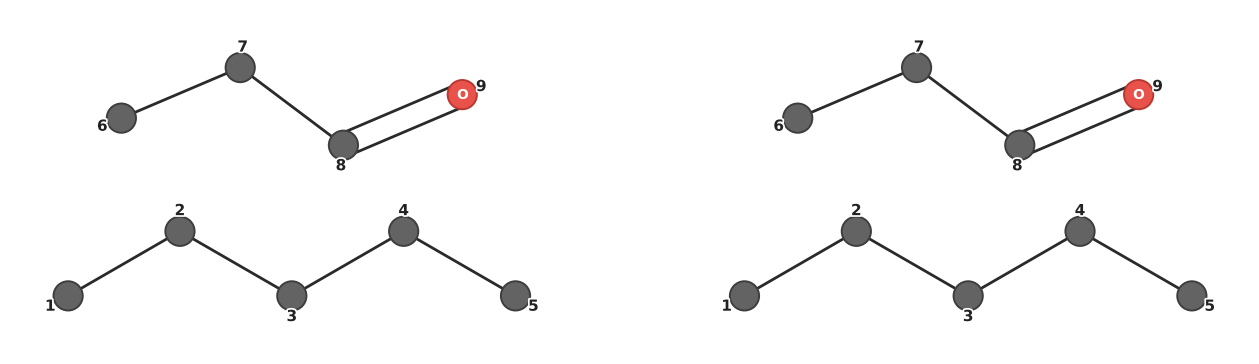

In [12]:
D1, mk1 = pushout_complement(L, K, G, matches[0])
D2, mk2 = pushout_complement(L, K, G, matches[1])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

draw_molecular_graph(
    D1,
    show_indices=True,
    ax=ax[0],
)

draw_molecular_graph(
    D2,
    show_indices=True,
    ax=ax[1],
)

#### Pushout complement: $G \to D$ (deletion step)

$D$ is obtained by removing the atoms/bonds in $L \setminus K$ from $G$.
The highlighted region in $G$ shows which nodes/edges are matched and will be deleted.

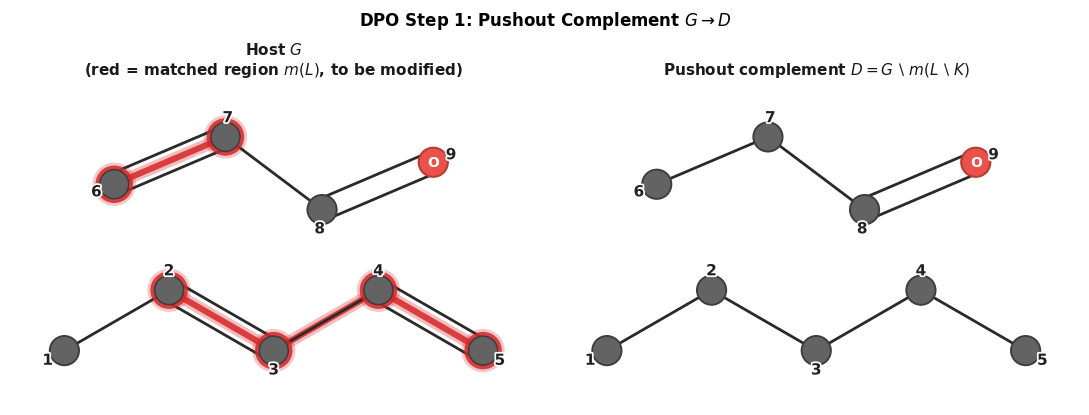

G: 9 nodes, 7 edges
D: 9 nodes, 7 edges


In [13]:
import matplotlib.pyplot as plt
from synedu.Utils.vis import draw_molecular_graph

# D1 already computed: D1, mk1 = pushout_complement(L, K, G, matches[0])
_matched_g_nodes = set(matches[0].values())
_matched_g_edges = {
    (u, v) for u, v in G.edges() if u in _matched_g_nodes and v in _matched_g_nodes
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor='white')

draw_molecular_graph(
    G,
    ax=axes[0],
    highlight_nodes=_matched_g_nodes,
    highlight_edges=_matched_g_edges,
    highlight_color='#D62728',
    show_indices=True,
    title='Host $G$\n(red = matched region $m(L)$, to be modified)',
)

draw_molecular_graph(
    D1,
    ax=axes[1],
    show_indices=True,
    title='Pushout complement $D = G \\setminus m(L \\setminus K)$',
)

fig.suptitle(
    'DPO Step 1: Pushout Complement $G \\to D$', fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
print(f'G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'D: {D1.number_of_nodes()} nodes, {D1.number_of_edges()} edges')

### 2.3 Pushout

Now we have $D$ and $m'$ (or $m_K$); with interface $K$ and right pattern $R$, we construct the pushout $H$


$$
  V(H)=V(D)\;\cup\;\bigl(V(R)\setminus V(K)\bigr)\ /\ \{\,x\sim m'(x)\ (x\in K)\,\},
  $$
  $$
  E(H)=E(D)\;\cup\;m''\bigl(E(R)\bigr),
$$
where $m'':V(R)\to V(H)$ maps $x\mapsto m_K(x)$ for $x\in K$ and sends $x\in V(R)\setminus V(K)$ to fresh copies in $H$.



In [14]:
def pushout(
    R: nx.Graph,
    K: nx.Graph,
    D: nx.Graph,
    m_K: Dict[Any, Any],
    *,
    order_key: str = "order",
    strict_id_freshness: bool = True,
) -> Tuple[nx.Graph, Dict[Any, Any]]:

    K_nodes = set(K.nodes())
    R_nodes = set(R.nodes())
    D_nodes = set(D.nodes())

    if not K_nodes.issubset(R_nodes):
        raise ValueError("K.nodes() must be subset of R.nodes()")
    if not set(m_K.keys()).issuperset(K_nodes):
        raise ValueError("m_K must be defined on all K nodes")
    if not set(m_K.values()).issubset(D_nodes):
        raise ValueError("m_K images must lie in D")

    # start with H = D
    H = D.copy()

    # build node map h: R -> H
    h: Dict[Any, Any] = {}

    # interface nodes: use m_K
    for k in K_nodes:
        h[k] = m_K[k]

    # nodes in R\K: create fresh nodes in H
    # (If IDs already exist in H and strict_id_freshness=False, reuse them.)
    for v in R_nodes - K_nodes:
        if v in H:
            if strict_id_freshness:
                raise ValueError(f"Node id collision outside K: {v}")
            # reuse existing id
            h[v] = v
        else:
            H.add_node(v, **dict(R.nodes[v]))
            h[v] = v

    # add edges from R (mapped into H) and relabel to R's order
    for u, v, edata in R.edges(data=True):
        hu, hv = h[u], h[v]

        if not H.has_node(hu) or not H.has_node(hv):
            raise ValueError(
                f"Internal error: mapped endpoints missing in H for R edge ({u},{v})"
            )

        if not H.has_edge(hu, hv):
            H.add_edge(hu, hv, **dict(edata))

        # relabel bond order to R's order (your semantics)
        if order_key not in edata:
            raise KeyError(f"R edge ({u},{v}) missing '{order_key}'")
        H.edges[hu, hv][order_key] = float(edata[order_key])

    return H, h

In [15]:
H1, h1 = pushout(R, K, D1, mk1)
H2, h2 = pushout(R, K, D2, mk2)

#### Pushout step by step

DPO rewriting proceeds in two stages:

1. **Pushout complement** $D = G \setminus m(L \setminus K)$ — remove the matched atoms/bonds that belong to $L$ but not $K$ (orange region).
2. **Pushout** $H = D \cup_K R$ — glue $R$ onto $D$ along the interface $K$.

Each panel below corresponds to one stage for match 1 of the Diels-Alder rule.

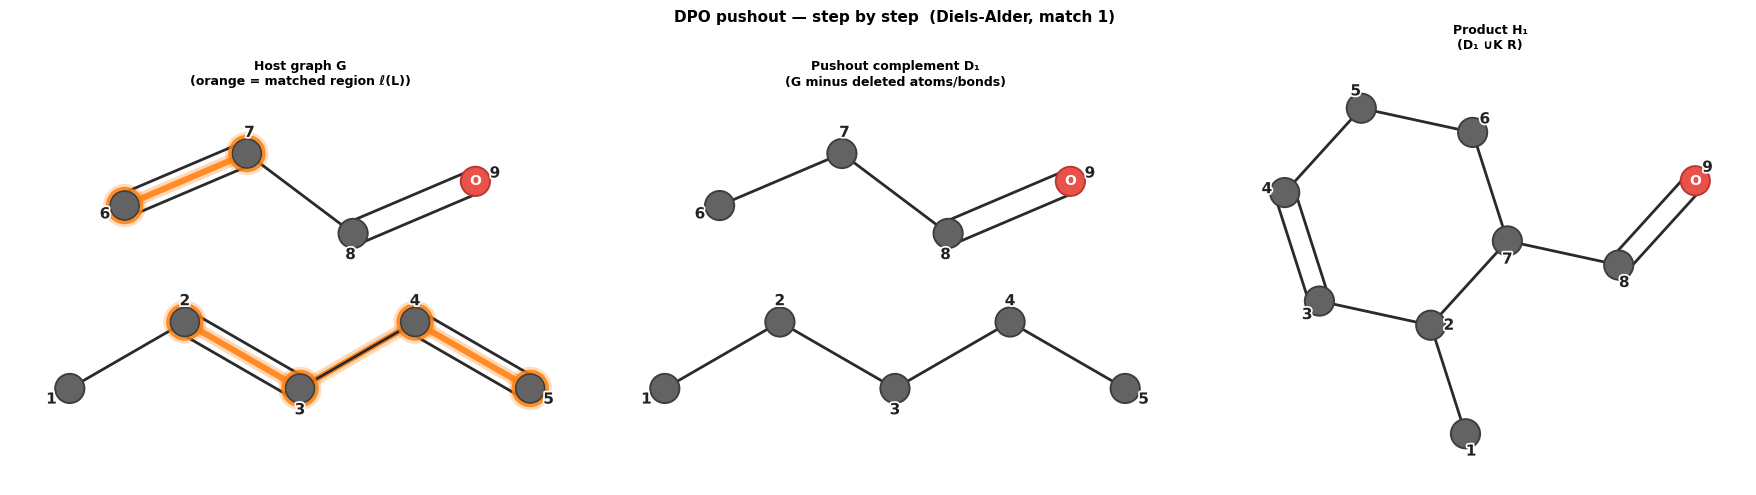

In [16]:
from synedu.Utils.vis import draw_molecular_graph
import matplotlib.pyplot as plt

# highlight the matched region of L in G
_matched_g_nodes = set(matches[0].values())
_matched_g_edges = {
    (u, v) for u, v in G.edges() if u in _matched_g_nodes and v in _matched_g_nodes
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "DPO pushout — step by step  (Diels-Alder, match 1)", fontsize=11, fontweight="bold"
)

draw_molecular_graph(
    G,
    ax=axes[0],
    show_indices=True,
    highlight_nodes=_matched_g_nodes,
    highlight_edges=_matched_g_edges,
    highlight_color="#FF7F0E",
)
axes[0].set_title(
    "Host graph G\n(orange = matched region ℓ(L))", fontsize=9, weight="bold"
)

draw_molecular_graph(D1, ax=axes[1], show_indices=True)
axes[1].set_title(
    "Pushout complement D₁\n(G minus deleted atoms/bonds)", fontsize=9, weight="bold"
)

draw_molecular_graph(H1, ax=axes[2], show_indices=True)
axes[2].set_title("Product H₁\n(D₁ ∪K R)", fontsize=9, weight="bold")

plt.tight_layout()
plt.show()

**Q3 — Implicit hydrogen**

Convert explicit hydrogen nodes into an integer `hcount` attribute on their bonded heavy atom.
Robust, configurable, and returns a new graph (or mutates in-place).

---

<details> <summary><b>Solution</b></summary>

```python
import networkx as nx
def h_to_implicit(G: nx.Graph) -> nx.Graph:
    """Convert explicit hydrogen atoms to implicit counts on heavy atoms.

    For each hydrogen atom ('element' == 'H'), its neighbor (assumed to be a heavy atom)
    will have its 'hcount' attribute incremented. The hydrogen nodes are then removed.

    Parameters
    ----------
    G : nx.Graph
        Input graph with explicit hydrogen atoms as nodes (element='H').
        Heavy atoms must have 'element' and optionally 'hcount' attributes.

    Returns
    -------
    nx.Graph
        A copy of the original graph with hydrogen atoms removed and their counts
        added to the corresponding heavy atoms' 'hcount' attribute.
    """
    H2 = G.copy()
    h_nodes = [n for n, d in H2.nodes(data=True) if d.get("element") == "H"]

    for h in h_nodes:
        neighbors = list(H2.neighbors(h))
        for heavy in neighbors:
            if H2.nodes[heavy].get("element") != "H":
                H2.nodes[heavy]["hcount"] = H2.nodes[heavy].get("hcount", 0) + 1
        H2.remove_node(h)

    return H2

```

</details>

Now we make it into 1 pipeline now

In [17]:
from synedu.Utils.conversion import graph_to_smi, smiles_to_graph
from synedu.Utils.reaction import rsmi_to_graph
from synedu.Utils.graph import h_to_implicit  # assume we have now


def dpo_rule_apply(smiles, rule):
    G = smiles_to_graph(smiles)
    L, R = rsmi_to_graph(rule)

    # 1. find match
    matches = find_pattern_match_components(host=G, pattern=L)

    # 2. Build pushout complement
    Ds, mks = zip(*(pushout_complement(L, K, G, m) for m in matches))

    # 3. Pushout
    Hs, _ = zip(*(pushout(R, K, D, mk) for D, mk in zip(Ds, mks)))
    Hs = [h_to_implicit(i) for i in list(Hs)]

    # 4 sanity check
    out_smi = [smi for H in Hs if (smi := graph_to_smi(H)) is not None]
    out_rsmi = [f'{smiles}>>{i}' for i in out_smi]
    return out_rsmi

In [18]:
# Now we define left and right patterns with atom map
input = 'CC=CC=C.C=CC=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
dpo_rule_apply(input, rule)

['CC=CC=C.C=CC=O>>CC1C=CCCC1C=O', 'CC=CC=C.C=CC=O>>CC1C=CCC(C=O)C1']

How do we obtain **atom maps** for the generated reactions?

In DPO rewriting we explicitly construct the transformation
$$
G \;\longrightarrow\; H,
$$
rather than inferring correspondence post hoc.

**Key observation**

- Nodes of the host graph \(G\) that are **preserved** through the
  pushout complement and pushout remain the *same graph nodes* in \(H\).
- Therefore, **node indices are preserved along the rewrite**.

**Consequence**

We can directly use the node index as the atom-map number:
$$
\texttt{atom\_map}(v) \;=\; \texttt{node\_id}(v),
\qquad v \in V(H).
$$

In [19]:
import networkx as nx
from typing import Hashable


def set_atom_map_from_node_index(
    G: nx.Graph,
    *,
    atom_map_attr: str = "atom_map",
    inplace: bool = False,
) -> nx.Graph:
    H = G if inplace else G.copy()

    for v in H.nodes:
        H.nodes[v][atom_map_attr] = v

    return H

In [20]:
def dpo_rule_apply(smiles, rule, use_aam=True):
    """
    Apply a DPO rewrite rule to an input SMILES.

    Pipeline:
      1) SMILES -> host graph G
      2) Rule -> L, R graphs
      3) Find injective matches m : L -> G
      4) Pushout complement: (D, m_K)
      5) Pushout: D + R -> H
      6) Convert explicit H to implicit hydrogens
      7) Graph -> product SMILES
    """
    # 0. Parse input
    G = smiles_to_graph(smiles)
    L, R = rsmi_to_graph(rule)

    # 1. Find matches m : L -> G
    matches = list(find_pattern_match_components(host=G, pattern=L))
    if not matches:
        return []

    # 2. Pushout complements
    Ds = []
    mks = []
    for m in matches:
        try:
            D, mk = pushout_complement(L, K, G, m)
        except ValueError:
            # dangling condition or invalid match
            continue
        Ds.append(D)
        mks.append(mk)

    if not Ds:
        return []

    # 3. Pushouts
    Hs = []
    for D, mk in zip(Ds, mks):
        try:
            H, _ = pushout(R, K, D, mk)
        except ValueError:
            continue
        Hs.append(h_to_implicit(H))

    if not Hs:
        return []

    if use_aam:
        G = set_atom_map_from_node_index(G)
        smiles = graph_to_smi(G)
        Hs = [set_atom_map_from_node_index(i) for i in Hs]
    # 4. Convert to SMILES (single evaluation, deduplicated)
    out_smi = {smi for H in Hs if (smi := graph_to_smi(H)) is not None}

    return [f"{smiles}>>{smi}" for smi in out_smi]

In [21]:
input = 'CC=CC=C.C=CC=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'
rsmi1, rsmi2 = dpo_rule_apply(input, rule, True)

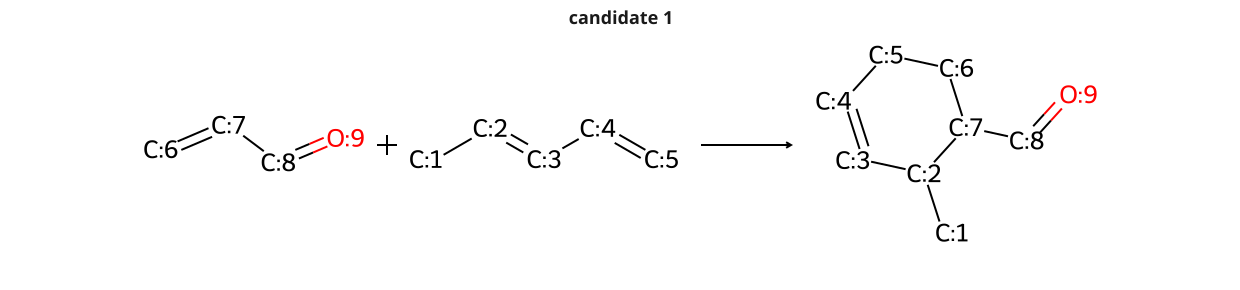

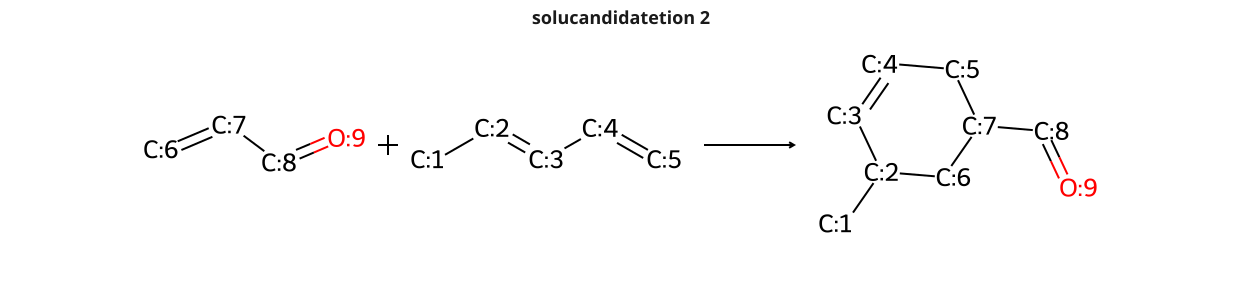

In [22]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG

svg1 = visualize_reaction(
    rsmi1,
    svg=True,
    highlight_changes=True,
    legend="candidate 1",
)
svg2 = visualize_reaction(
    rsmi2,
    svg=True,
    highlight_changes=True,
    legend="solucandidatetion 2",
)
display(SVG(svg1))
display(SVG(svg2))

**Q4 — Inverse rule application**

Given an input SMILES `CC1C=CCCC1C=O`, can we apply the **inverse** of the above rule?

---

<details> <summary><b>Solution</b></summary>

Yes.  
In DPO rewriting, a rule
$$
p:\quad L \xleftarrow{} K \xrightarrow{} R
$$
is inverted simply by **swapping $L$ and $R$**. The same categorical
construction (match → pushout complement → pushout) applies.


```python

def dpo_rule_apply(smiles, rule, use_aam=True, inverse = False):

    # 0. Parse input
    G = smiles_to_graph(smiles)
    
    if inverse:
        R, L = rsmi_to_graph(rule)
    else:
        L, R = rsmi_to_graph(rule)

    # 1. Find matches m : L -> G
    matches = list(find_pattern_match_components(host=G, pattern=L))
    if not matches:
        return []

    # 2. Pushout complements
    Ds = []
    mks = []
    for m in matches:
        try:
            D, mk = pushout_complement(L, K, G, m)
        except ValueError:
            # dangling condition or invalid match
            continue
        Ds.append(D)
        mks.append(mk)

    if not Ds:
        return []

    # 3. Pushouts
    Hs = []
    for D, mk in zip(Ds, mks):
        try:
            H, _ = pushout(R, K, D, mk)
        except ValueError:
            continue
        Hs.append(h_to_implicit(H))

    if not Hs:
        return []

    if use_aam:
        G = set_atom_map_from_node_index(G)
        smiles = graph_to_smi(G)
        Hs = [set_atom_map_from_node_index(i) for i in Hs]
    # 4. Convert to SMILES (single evaluation, deduplicated)
    out_smi = {
        smi
        for H in Hs
        if (smi := graph_to_smi(H)) is not None
    }

    return [f"{smiles}>>{smi}" for smi in out_smi]

```

</details>

## 3. SynKit

Instead of implementing the full DPO pipeline manually, we can directly use
`SynReactor` from **SynKit**, which natively supports DPO rewriting with
implicit hydrogens.

In [23]:
from synkit.Synthesis.Reactor.syn_reactor import SynReactor

input = 'CC1C=CCCC1C=O'
rule = '[C:5]=[C:6].[C:2]([C:3]=[C:4])=[C:1]>>[C:2]1=[C:3][C:4][C:5][C:6][C:1]1'

reactor = SynReactor(
    substrate=input,
    template=rule,
    invert=True,
    implicit_temp=True,
    explicit_h=False,
    automorphism=True,
)
reactor.smarts

2026-05-22 15:09:13,082 - INFO - 1 mapping(s) discovered


['[CH2:6]=[CH:7][CH:8]=[O:9].[CH3:1][CH:2]=[CH:3][CH:4]=[CH2:5]>>[CH3:1][CH:2]1[CH:3]=[CH:4][CH2:5][CH2:6][CH:7]1[CH:8]=[O:9]']

### Forward vs inverse rule application

The same DPO span $L \xleftarrow{l} K \xrightarrow{r} R$ works in both directions:
- **Forward**: Diels–Alder cyclization (diene + dienophile → cyclohexene)
- **Inverse**: retrosynthetic disconnection (cyclohexene → diene + dienophile)

Swapping $L$ and $R$ is all it takes.

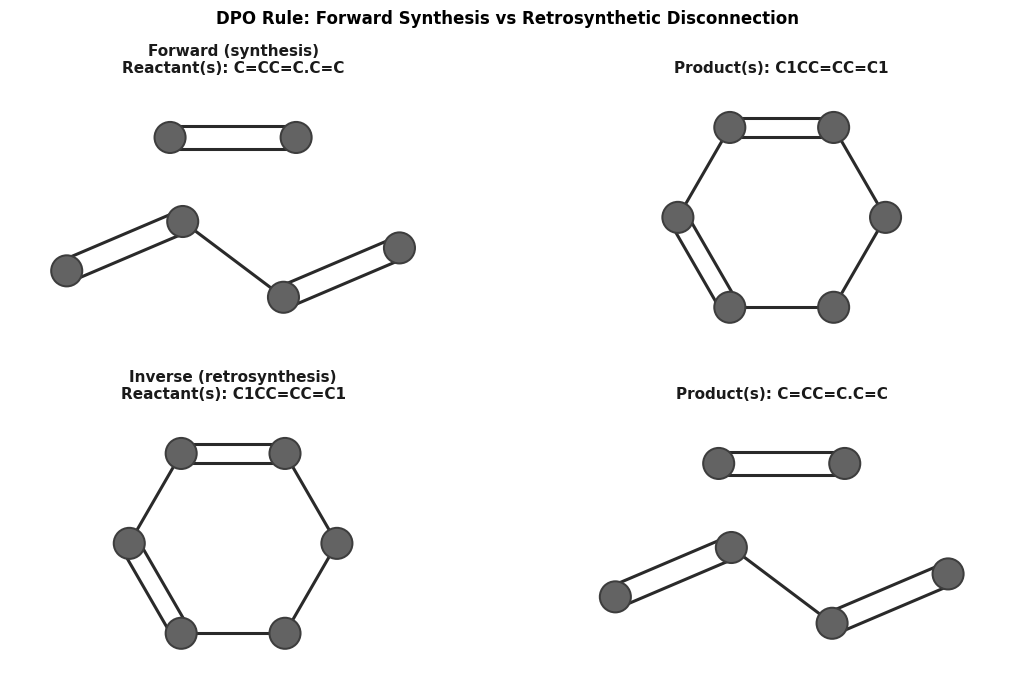

In [24]:
import matplotlib.pyplot as plt
from synedu.Utils.vis import draw_molecular_graph
from synedu.Utils.conversion import smiles_to_graph, graph_to_smi

# Forward: diene + dienophile → cyclohexene
_fw_rsmi = 'C=CC=C.C=C>>C1CC=CC=C1'  # Diels-Alder
# Inverse: cyclohexene → open chain
_bw_rsmi = 'C1CC=CC=C1>>C=CC=C.C=C'

_pairs = [('Forward (synthesis)', _fw_rsmi), ('Inverse (retrosynthesis)', _bw_rsmi)]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), facecolor='white')

for row, (direction, rsmi) in enumerate(_pairs):
    parts = rsmi.split('>>')
    _r_smi, _p_smi = parts[0], parts[1]
    try:
        from synedu.Utils.reaction import rsmi_to_graph as _r2g

        _rg, _pg = _r2g(rsmi)
        draw_molecular_graph(
            _rg, ax=axes[row, 0], title=f'{direction}\nReactant(s): {_r_smi}'
        )
        draw_molecular_graph(_pg, ax=axes[row, 1], title=f'Product(s): {_p_smi}')
    except Exception as e:
        for col in range(2):
            axes[row, col].text(
                0.5,
                0.5,
                str(e)[:60],
                transform=axes[row, col].transAxes,
                ha='center',
                va='center',
                fontsize=8,
            )
            axes[row, col].set_axis_off()

fig.suptitle(
    'DPO Rule: Forward Synthesis vs Retrosynthetic Disconnection',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 4. Quiz

Answer the following questions using **formal DPO graph-rewriting terminology**.

---

### 1. The Dangling Condition

A match $m: L \hookrightarrow G$ *violates the dangling condition* when an edge $e \in E(G)$ is incident to a to-be-deleted node $m(v)$, $v \in V(L) \setminus V(K)$, but $e \notin m(E(L))$.

- **a)** Give a chemical example where the dangling condition is violated. What happens to the substrate graph if we ignore it?
- **b)** Describe two strategies for handling dangling edges. Which does SynReactor use, and why?

---

### 2. DPO Uniqueness

Given a valid match $m: L \hookrightarrow G$, is the pushout complement $D$ always unique up to isomorphism?

- State the precise mathematical condition guaranteeing uniqueness.
- Can two *different* valid matches $m_1 \neq m_2$ yield isomorphic products $H_1 \cong H_2$? Give a chemical example involving a symmetric substrate.

---

### 3. Inverse Rules and Retrosynthesis

The *inverse* of a DPO rule $p: L \xleftarrow{\,l\,} K \xrightarrow{\,r\,} R$ is $p^{-1}: R \xleftarrow{\,r\,} K \xrightarrow{\,l\,} L$.

- **a)** Implement `invert_rule(L, K, R) -> (R, K, L)` in one line.
- **b)** Show that applying the Diels–Alder rule in inverse mode corresponds to the retrosynthetic disconnection of the cyclohexene ring.
- **c)** Does the dangling condition still apply to $p^{-1}$? Is there an additional condition?

<details>
<summary><b>Hint</b></summary>

The inverse rule deletes the bonds $R \setminus K$ and creates bonds $L \setminus K$.  
The dangling condition for $p^{-1}$ is checked in $G$ (the product) the same way as for $p$.
</details>

---

### 4. Rule Composition

Two rules $p_1: L_1 \leftarrow K_1 \rightarrow R_1$ and $p_2: L_2 \leftarrow K_2 \rightarrow R_2$ can be composed when there exists an injective morphism $R_1 \hookrightarrow L_2$ that is compatible with the $K$-embedding.

- **a)** When is the composed rule well-defined (no orphan nodes)?
- **b)** Describe chemically a "Diels–Alder then oxidation" composed rule. What would $K_{12}$ preserve?

---

### 5. Orbit-Aware Deduplication (connection to S02)

The Diels–Alder pattern $L$ contains the diene fragment $C=C{-}C=C$.

- **a)** Is $|\mathrm{Aut}(L)| > 1$? If so, identify the non-trivial automorphism.
- **b)** If there are $n$ total injective matches $m: L \hookrightarrow G$ and $|\mathrm{Aut}(L)| = k$, what is the maximum number of orbit-distinct products?
- **c)** Modify the pipeline so that orbit-equivalent matches are detected and collapsed before rule application.


## 5. Discussion

### Key Takeaways

**DPO graph rewriting provides a precise, reversible, and composable framework for reaction rules.**

---

#### The span representation

A reaction rule as a span $L \xleftarrow{\,l\,} K \xrightarrow{\,r\,} R$ cleanly separates:

| Component | Meaning | Chemical interpretation |
|---|---|---|
| $L \setminus K$ | deleted items | bonds broken, atoms leaving |
| $K$ | preserved context | atoms present in both reactant and product |
| $R \setminus K$ | created items | bonds formed, atoms added |

This is *exactly* the non-zero off-diagonal entries of the ΔBE matrix introduced in **S01**.

---

#### The dangling condition

The dangling condition is not a limitation — it is a *correctness guarantee*. Ignoring it would produce invalid graphs (edges pointing to deleted nodes). In practice, SynKit resolves this by tracking implicit hydrogens separately: an atom deleted from the heavy-atom graph implicitly releases its H-count, which is then re-assigned after the rewrite.

---

#### Reversibility

DPO rules are **naturally invertible**: swapping $L$ and $R$ turns any forward synthesis rule into a retrosynthetic disconnection rule. This is the theoretical foundation for the backward prediction pipeline in **S08**: the same `SynReactor` engine is reused with $L$ and $R$ exchanged.

---

#### Orbit-aware deduplication (connection to S02)

Two matches $m_1, m_2: L \hookrightarrow G$ that differ only by an automorphism of $L$ produce **isomorphic** products $H_1 \cong H_2$. Collapsing them before running the rewrite avoids redundant computation and prevents inflated candidate lists in the prediction pipeline (**S08**).

---

#### Practical limitations

- **NP-completeness**: Pattern matching (subgraph isomorphism) is NP-complete in general, but sparse molecular graphs keep it tractable in practice.
- **Selectivity**: A rule with a small $K$ (minimal context) fires many times; one with a large $K$ fires rarely. The trade-off between specificity and coverage is studied quantitatively in **S09**.
- **Rule composition**: Chaining two DPO rules into a single multi-step pathway requires careful handling of intermediate graphs. This is an active research direction beyond the current series.

---

### Connection to the rest of the series

| Concept | First seen | Re-used in |
|---|---|---|
| DPO span $L \leftarrow K \rightarrow R$ | **S05** (here) | S07 (rule library), S08 (prediction), S09 (context) |
| Orbit-aware match dedup | S02 | S07 (WL clustering), S08 (candidate dedup) |
| Rule inversion | **S05** (here) | S08 (backward prediction) |
| ITS graph as $K$-encoding | S04 | S06 (canonicalization), S07 (clustering) |
| ΔBE ↔ span equivalence | S01 (ΔBE), S05 (span) | S07 (rule fingerprint) |
